## 这是一个yolo11的识别手部关键点的example 

### 注意需要提前安装opencv-python,pillow,numpy,scipy,matplotlib,torch,torchvision,ultralytics

### 同时要在Python文件夹把TFDL的python代码也安装好

<Warning>[Tue Jul  8 13:38:18 2025 ]: /root/NPU-SDK/TFDL2_SDK/Example/PythonDevelop/libTFDLAddOn.so: cannot open shared object file: No such file or directory
Detect Host is @ThinkForce.Inc NPU40T
TFNN Compiled at May  7 2025, 15:21:50
Init NPU40T:2


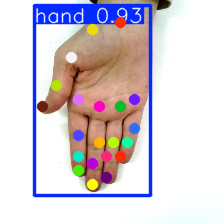

1

In [1]:
from ultralytics import YOLO
from PIL import ImageShow
from PIL import Image
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
ishow = ImageShow.IPythonViewer()
from TFDL2 import TFExecutor,TFContext,Option
import cv2
import numpy as np
import os

# 准备模型上下文
context = TFContext(path="./yolo11s_handposeQ.fb")
#准备模型编译参数
newopention = Option
newopention["UseHardware"] = True # 是否使用硬件
newopention["FrugalMode"] = True # 是否使用精简模式,即推理时中间层内存地址会进行复用。
newopention["useCache"] = True # 是否使用tfacc缓存
newopention["Core"] = [-1] # 使用哪些核心 -1 表示使用任意大核 -2 表示使用任意小核，[0,1,2,3] 表示使用大核0，大核1，大核2，大核3。[4,5,6,7] 表示使用小核0，小核1，小核2，小核3
newopention["optimize"]["MakeAlign"] = True # 是否使用对齐优化
newopention["optimize"]["MakeUnfold"] = True # 是否将部分硬件不支持的卷积操作进行展开
newopention["InputShape"] = [
    #{"NodeName":"input.1","Shape":[1,3,288,512]},
    #{"NodeName":"TFDL_Placeholder_0","Shape":[1,3,288,512]},
    {"NodeName":"images","Shape":[1,3,288,512]},
]
def preprocess(im,imgsz):# yolo 预处理
        #im = np.stack(im)
        im = cv2.cvtColor(im,cv2.COLOR_BGR2RGB)
        im = cv2.resize(im,imgsz)
        im = im[np.newaxis,:]
        im = im.transpose((0, 3, 1, 2))  # BGR to RGB, BHWC to BCHW, (n, 3, h, w)
        im = np.ascontiguousarray(im)  # contiguous
        #im /= 255  # 0 - 255 to 0.0 - 1.0
        return im

#准备图片
orig_img = cv2.imread("test.jpg",-1)
#设置编译参数中的输入尺寸
newopention["InputShape"][0]["Shape"] = [1,3,*orig_img.shape[:2]]

#预处理图片
img = preprocess(orig_img,newopention["InputShape"][0]["Shape"][::-1][:2])

# 开始编译模型运行时，对于视频流的推理，因为输入尺寸一般是确定的，所以编译一次即可之后这个model可以复用，对于图片流，每次输入尺寸不同，需要每次编译.
# 注意context不要释放，因为虽然编译出来的运行时是独立的，但是模型权重是共享的，所以context不要释放，否则运行时无法加载模型权重。
model = TFExecutor(context=context,config=newopention)

#获取输入的handle
inputs = model.GetInputs()[0]
#img = img.astype(np.float32)
#将输入数据通过numpy喂进去
inputs.fromNumpy(img)
#开始推理,并获得全部输出的handle,对于yolo 它的输出只有一个,且都是float32类型
out = model()[0].toNumpy()

#后处理,直接使用ultralytics的代码
import torch
from ultralytics.data.augment import LetterBox
from ultralytics.engine.results import Results,Boxes
from types import SimpleNamespace
import yaml
from ultralytics.utils import ops
threshold = 0.3
mode = "POSE"
names = {0:"hand"}
kpt_shape = [21, 3]
out = torch.from_numpy(out)
preds = ops.non_max_suppression(
                        out,
                        threshold,
                        0.45,
                        nc=1,
                    )
results = []
if mode == "DET":
                        for i, pred in enumerate(preds):
                            #orig_img = orig_imgs[i]
                            pred[:, :4] = ops.scale_boxes(img.shape[2:], pred[:, :4], orig_img.shape)
                            results.append(Results(orig_img,path=None, names=names, boxes=pred))

elif mode == "POSE":
                        for i, pred in enumerate(preds):
                            pred[:, :4] = ops.scale_boxes(img.shape[2:], pred[:, :4], orig_img.shape).round()
                            pred_kpts = pred[:, 6:].view(len(pred), *kpt_shape) if len(pred) else pred[:, 6:]
                            pred_kpts = ops.scale_coords(img.shape[2:], pred_kpts, orig_img.shape)
                            results.append(
                                Results(orig_img, path=None, names=names, boxes=pred[:, :6], keypoints=pred_kpts)
                            )
                    
ishow.show(Image.fromarray(cv2.cvtColor(results[0].plot(),cv2.COLOR_BGR2RGB)))